Create project_root to allow access to train.csv and then read train.csv to train_df.

In [2]:
import os
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

project_root = os.path.dirname(os.getcwd())
train_df = pd.read_csv(os.path.join(project_root, "data", "raw", "train.csv"))

Head of train_df

In [4]:
print(train_df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

Shape and column names of train_df

In [5]:
print(f"Shape: {train_df.shape}\n")
print(f"Columns: {train_df.columns}")

Shape: (1460, 81)

Columns: Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
    

Info of train_df

In [14]:
print(train_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

Get all of the columns with missing data points and rank them in order of how many data points are missing

In [12]:
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Columns with missing data points, ranked from most missing to least missing:\n\n{missing}")

Columns with missing data points, ranked from most missing to least missing:

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


Will get rid of all columns with over 600 missing values as this accounts for ~41% of the total number of houses. Thus I believe imputing these columns will introduce large volumes of fabricated data which would negatively effect our models in training. Below I will produce a scatter plot for LotFrontage as while it also has many missing values I believe it will have a strong correlation to SalePrice.

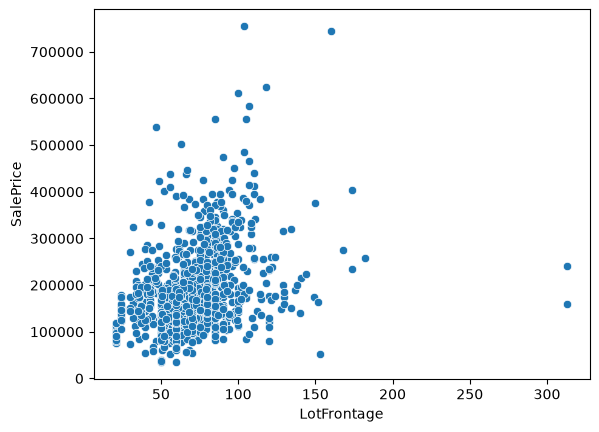

In [13]:
sns.scatterplot(data=train_df, x=train_df["LotFrontage"], y=train_df["SalePrice"])
plt.show()

Now want to find out which columns are numerical and which are categorical, this will allow us to decide what we will use to train our model and how we will impute the columns with missing values.

In [16]:
numeric_columns = [ col for col in train_df.columns if train_df[col].dtype in ("int64", "float64")]
categorical_columns = list(set(train_df.columns) - set((numeric_columns)))

print(f"Numerical Columns: {numeric_columns}\n")
print(f"Categorical Columns: {categorical_columns}")

Numerical Columns: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categorical Columns: ['Functional', 'Street', 'Exterior2nd', 'GarageType', 'PoolQC', 'LandSlope', 'CentralAir', 'Alley', 'BsmtCond', 'Foundation', 'Fence', 'LotConfig', 'ExterQual', 'MSZoning', 'BsmtQual', 'Heating', 'GarageFinish', 'Exterior1st', 'Neighborhood', 'BsmtExposure', 'Utilities', 'MiscFeature', 'BsmtFinType2', 'RoofMatl', 'Electrical', 'ExterCond', 'FireplaceQu', 'LandContour', 'BldgType', 'PavedDrive', 'Condition2', 'GarageCond', 'HouseStyle',

Want to take a deeper look at the two major outliers in the LotFrontage and see if they are worth keeping or if perhaps they were input incorrectly

In [13]:
outlier_index = train_df[train_df["LotFrontage"] > 300].index
print(f"Average LotArea: {train_df["LotArea"].mean()}")
print(f"Median LotArea: {train_df["LotArea"].median()}")
print(f"Average LotFrontage: {train_df["LotFrontage"].mean()}")
print(f"Median LotFrontage: {train_df["LotFrontage"].median()}")
print(f"Average SalePrice: {train_df["SalePrice"].mean()}")
print(f"Median SalePrice: {train_df["SalePrice"].median()}\n")

outlier_comparison = train_df.loc[outlier_index, ["LotFrontage", "LotArea", "Neighborhood", "SalePrice"]]
print(outlier_comparison)

Average LotArea: 10516.828082191782
Median LotArea: 9478.5
Average LotFrontage: 70.04995836802665
Median LotFrontage: 69.0
Average SalePrice: 180921.19589041095
Median SalePrice: 163000.0

      LotFrontage  LotArea Neighborhood  SalePrice
934         313.0    27650        NAmes     242000
1298        313.0    63887      Edwards     160000


Now we will begin cleaning our training data by filling in the missing values for columns, completely removing columns with too many missing values and any other prep required. This will be done in the main src folder

In [14]:
print(train_df["Electrical"].dtype)

str
